# <center>**Tecnológico de Costa Rica**</center>

***IC-6200 / Inteligencia artificial***

Profesor

*   **Efren Jimenez Delgado**

Proyecto JarvisTEC, I Semestre 2026

## Análisis del Problema

Queremos estimar el **precio de cierre del Bitcoin en dólares** para el día siguiente y hasta siete días después del último dato disponible. Es un problema de **regresión sobre una serie de tiempo** a partir de la columna `Close`. Para modelarlo se usa como objetivo el retorno logarítmico del día siguiente.

La referencia obligada es la **persistencia** ("mañana = hoy"). La hipótesis de los mercados eficientes en su forma débil (Fama, 1970) dice que el historial de precios no sirve para predecir los precios futuros, y en la literatura de tipos de cambio ningún modelo estimado mejoró de forma consistente al paseo aleatorio fuera de muestra (Meese y Rogoff, 1983). Por eso la pregunta no es "qué error tiene el modelo" sino **si mejora de forma demostrable a repetir el último precio**.

Los datos terminan el 31 de julio de 2017: "mañana" es el 1 de agosto de 2017 y el modelo no conoce el precio actual.

# Caso Aplicado: Precio del Bitcoin
## Serie de tiempo, predicción recursiva y comparación contra la persistencia

---

**Temas:** Series de tiempo · Retornos logarítmicos · Predicción recursiva · Línea base de persistencia · Intervalos de predicción  
**Herramientas:** Python · Pandas · Scikit-learn · Seaborn

---

### El hilo conductor

| Etapa | Pregunta central |
|---|---|
| 1 — Entendimiento | ¿Cómo vienen los datos y por qué no se pueden usar variables como el volumen? |
| 2 — Exploración | ¿Los retornos tienen estructura que un modelo pueda aprovechar? |
| 3 — Modelo | ¿Algún modelo supera a repetir el último precio? |
| 4 — Evaluación | ¿Cómo crece el error con los días y qué tan confiable es el rango del 95 %? |

> Nota: en una serie de precios, un modelo que "predice bien" puede estar repitiendo el último valor. Siempre hay que compararlo contra esa referencia, y contra la tendencia media (la deriva).

Este notebook es un extra del modelo 01 del proyecto: reproduce de forma didáctica el entrenamiento que hace `train.py` y se puede probar en Google Colab. No reemplaza al código del repositorio.

### Autores

   * Equipo JarvisTEC (proyecto de la primera etapa)

### Librerías

In [1]:
# Manejo de datasets
import pandas as pd
import numpy as np
# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# Ignorar Warnings
import warnings
warnings.filterwarnings('ignore')

SEMILLA = 42

---
# Sección 1: Entendimiento de los Datos
---

## Entendimiento de los Datos

El conjunto tiene precios diarios del Bitcoin del 28 de abril de 2013 al 31 de julio de 2017:

- Date       : fecha, como texto (por ejemplo `Jul 31, 2017`)
- Open, High, Low, Close : precios de apertura, máximo, mínimo y cierre en dólares
- Volume     : volumen negociado, con separadores de miles y `-` cuando falta
- Market Cap : capitalización de mercado

Las filas vienen de la fecha más reciente a la más antigua, así que hay que ordenarlas.

Los datos están en el archivo `dataset.csv` de la carpeta `backend/features/modelo_01_bitcoin/` del repositorio. Son 1 556 filas y 7 columnas.

En Colab hay dos formas de usarlo: arrastrarlo al panel de archivos (queda en `sample_data/`) o subirlo cuando la celda lo pida.

In [2]:
# Ubicar el archivo de datos (Colab o ejecución local)
import os

RUTA = next((r for r in ("sample_data/dataset.csv", "dataset.csv") if os.path.exists(r)), None)
if RUTA is None:
    try:
        from google.colab import files
        print("Seleccione el archivo dataset.csv")
        RUTA = next(iter(files.upload()))
    except ImportError:
        raise FileNotFoundError("No se encontró dataset.csv: colóquelo en sample_data/ o en la carpeta actual")
print("Archivo de datos:", RUTA)

Archivo de datos: sample_data/dataset.csv


In [3]:
# Cargar los datos
datos = pd.read_csv(RUTA)
datos.head()

,Date,Open,High,Low,Close,Volume,Market Cap
0,"Jul 31, 2017",2763.24,2889.62,2720.61,2875.34,"860,575,000","45,535,800,000"
1,"Jul 30, 2017",2724.39,2758.53,2644.85,2757.18,"705,943,000","44,890,700,000"
2,"Jul 29, 2017",2807.02,2808.76,2692.80,2726.45,"803,746,000","46,246,700,000"
3,"Jul 28, 2017",2679.73,2897.45,2679.73,2809.01,"1,380,100,000","44,144,400,000"
4,"Jul 27, 2017",2538.71,2693.32,2529.34,2671.78,"789,104,000","41,816,500,000"


In [4]:
# Información del dataset
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        1556 non-null   str    
 1   Open        1556 non-null   float64
 2   High        1556 non-null   float64
 3   Low         1556 non-null   float64
 4   Close       1556 non-null   float64
 5   Volume      1556 non-null   str    
 6   Market Cap  1556 non-null   str    
dtypes: float64(4), str(3)
memory usage: 85.2 KB


In [5]:
df = datos.copy()
df["fecha"] = pd.to_datetime(df["Date"], format="%b %d, %Y")
df["volumen"] = pd.to_numeric(df["Volume"].str.replace(",", "").replace("-", np.nan))
df = df.rename(columns={"Close": "cierre", "Open": "apertura", "High": "maximo", "Low": "minimo"})
df = df[["fecha", "apertura", "maximo", "minimo", "cierre", "volumen"]].sort_values("fecha").reset_index(drop=True)

print("Filas:", len(df), " Rango:", df["fecha"].min().date(), "a", df["fecha"].max().date())
print("Días entre registros consecutivos:", df["fecha"].diff().dt.days.value_counts().to_dict(), "| fechas repetidas:", int(df["fecha"].duplicated().sum()))
print("Volumen faltante:", int(df["volumen"].isna().sum()), "filas, todas antes de", df[df["volumen"].notna()]["fecha"].min().date())
df["cierre"].describe().round(2)

Filas: 1556  Rango: 2013-04-28 a 2017-07-31
Días entre registros consecutivos: {1.0: 1555} | fechas repetidas: 0
Volumen faltante: 243 filas, todas antes de 2013-12-27


count    1556.00
mean      584.24
std       525.90
min        68.43
25%       254.32
50%       438.86
75%       663.40
max      2958.11
Name: cierre, dtype: float64

Hay un registro por cada día, sin huecos, y eso es importante para la predicción recursiva. El cierre pasa de 134 a más de 2 800 dólares.

**Variables que se excluyen.** Para predecir varios días hay que encadenar predicciones: el cierre estimado de mañana entra al cálculo de pasado mañana. Eso solo es posible con variables que el propio modelo pueda producir, es decir, **cierres pasados**. La apertura, el máximo, el mínimo y el volumen del día siguiente no se conocen al consultar ni se pueden predecir por separado. El volumen, además, falta en los primeros 243 días.

**Objetivo.** No se predice el precio, sino el retorno logarítmico del día siguiente, log(cierre de mañana / cierre de hoy). El precio se recupera como cierre por exp(retorno). Así el modelo no tiene que aprender la escala, que cambió unas 20 veces a lo largo de la serie.

---
# Sección 2: Exploración de los Datos
---

## Exploración de los Datos

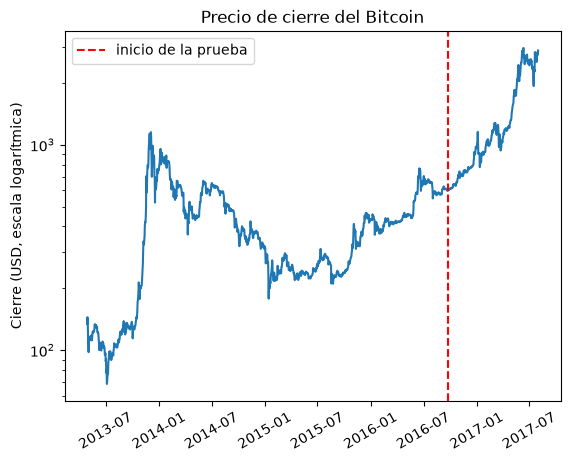

Inicio de la prueba: 2016-09-23 | el precio se multiplica por 4.77 dentro de la prueba


In [6]:
plt.semilogy(df["fecha"], df["cierre"])
corte = int(len(df) * 0.8)
plt.axvline(df["fecha"][corte], color="red", linestyle="--", label="inicio de la prueba")
plt.legend()
plt.ylabel("Cierre (USD, escala logarítmica)")
plt.title("Precio de cierre del Bitcoin")
plt.xticks(rotation=30)
plt.show()
print("Inicio de la prueba:", df["fecha"][corte].date(), "| el precio se multiplica por %.2f dentro de la prueba" % (df["cierre"].iloc[-1] / df["cierre"][corte]))

La prueba (el último 20 % de los días) es un mercado **alcista**: el precio se multiplica por casi cinco. Esto importa para interpretar cualquier métrica de dirección.

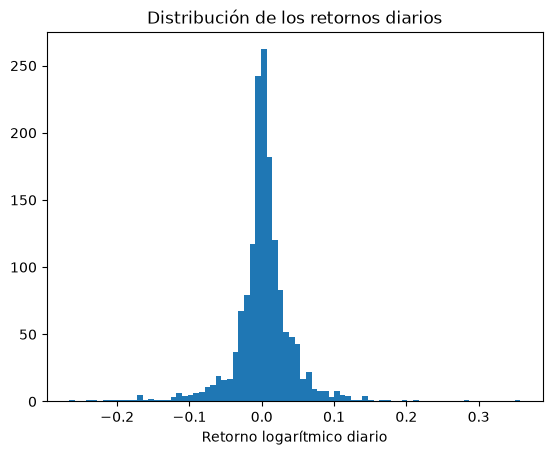

Media 0.0020  Desviación 0.0426  Mínimo -0.266  Máximo 0.357
Curtosis en exceso: 10.3 (la normal tiene 0)
Días en que el precio sube: 54.5 %


In [7]:
r = np.log(df["cierre"]).diff().dropna()
plt.hist(r, bins=80)
plt.xlabel("Retorno logarítmico diario")
plt.title("Distribución de los retornos diarios")
plt.show()
print("Media %.4f  Desviación %.4f  Mínimo %.3f  Máximo %.3f" % (r.mean(), r.std(), r.min(), r.max()))
print("Curtosis en exceso: %.1f (la normal tiene 0)" % r.kurt())
print("Días en que el precio sube: %.1f %%" % (100 * (r > 0).mean()))

Los retornos tienen **colas pesadas**: hay días con retornos logarítmicos de -0.27 y de +0.36 (más de seis desviaciones), algo que una distribución normal casi no permitiría.

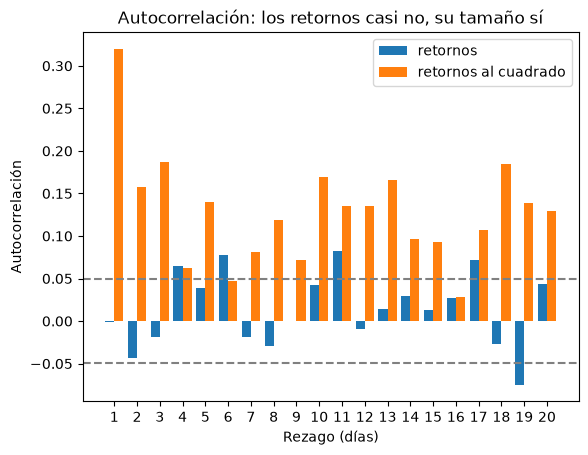

Retornos, rezagos 1 a 5: [-0.001 -0.043 -0.019  0.064  0.039] | cota del 95 %: +-0.050
Retornos al cuadrado, rezagos 1 a 5: [0.32  0.158 0.187 0.062 0.14 ]


In [8]:
def autocorrelacion(x, rezagos=20):
    x = np.asarray(x, dtype=float) - np.mean(x)
    return np.array([np.sum(x[k:] * x[:-k]) / np.sum(x ** 2) for k in range(1, rezagos + 1)])

rezagos = np.arange(1, 21)
cota = 1.96 / np.sqrt(len(r))
plt.bar(rezagos - 0.2, autocorrelacion(r.to_numpy()), width=0.4, label="retornos")
plt.bar(rezagos + 0.2, autocorrelacion(r.to_numpy() ** 2), width=0.4, label="retornos al cuadrado")
plt.axhline(cota, color="gray", linestyle="--")
plt.axhline(-cota, color="gray", linestyle="--")
plt.xticks(rezagos)
plt.xlabel("Rezago (días)")
plt.ylabel("Autocorrelación")
plt.legend()
plt.title("Autocorrelación: los retornos casi no, su tamaño sí")
plt.show()
print("Retornos, rezagos 1 a 5:", autocorrelacion(r.to_numpy(), 5).round(3), "| cota del 95 %%: +-%.3f" % cota)
print("Retornos al cuadrado, rezagos 1 a 5:", autocorrelacion(r.to_numpy() ** 2, 5).round(3))

La autocorrelación de los retornos es casi nula (algunos rezagos aislados superan la cota por poco), mientras que la de los retornos al cuadrado es alta: **el signo del movimiento casi no se repite, pero su tamaño sí**. Eso se llama agrupamiento de la volatilidad.

> Analogía: es como el clima. Que hoy haya llovido poco dice casi nada de si mañana lloverá, pero una semana de tormentas hace probable que mañana también sea tormentoso. La dirección es impredecible, la intensidad tiene memoria.

In [9]:
df.assign(ret=np.log(df["cierre"]).diff()).groupby(df["fecha"].dt.year)["ret"].std().round(4)

fecha
2013    0.0672
2014    0.0394
2015    0.0368
2016    0.0252
2017    0.0435
Name: ret, dtype: float64

La volatilidad cambia mucho con el tiempo (la de 2013 fue más del doble que la de 2016). Eso importa para el intervalo que se calcula más abajo.

---
# Sección 3: Ajuste del Modelo
---

## Modelo de Machine Learning

### Variables construidas

Todas se calculan **solo con cierres pasados**: retornos de 1 a 5, 7 y 30 días, distancia del cierre a su media de 7 y 30 días (en logaritmos) y desviación de los retornos de 7 y 30 días. Se necesitan 31 cierres para calcularlas todas.

In [10]:
VENTANA_MINIMA = 31
CARACTERISTICAS = ["ret_1", "ret_2", "ret_3", "ret_4", "ret_5", "ret_7", "ret_30", "dist_media_7", "dist_media_30", "vol_7", "vol_30"]

def caracteristicas(cierres):
    """Una fila por día usando solo los cierres hasta ese día."""
    c = pd.Series(np.asarray(cierres, dtype=float))
    lc = np.log(c)
    r = lc.diff()
    return pd.DataFrame({
        "ret_1": r, "ret_2": r.shift(1), "ret_3": r.shift(2), "ret_4": r.shift(3), "ret_5": r.shift(4),
        "ret_7": lc - lc.shift(7), "ret_30": lc - lc.shift(30),
        "dist_media_7": lc - np.log(c.rolling(7).mean()), "dist_media_30": lc - np.log(c.rolling(30).mean()),
        "vol_7": r.rolling(7).std(), "vol_30": r.rolling(30).std(),
    })[CARACTERISTICAS]

cierres = df["cierre"].to_numpy()
X = caracteristicas(cierres)
y = pd.Series(np.log(cierres)).diff().shift(-1)          # retorno del día siguiente
validas = X.notna().all(axis=1) & y.notna()
X, y = X[validas], y[validas]
print("Filas con características y objetivo:", len(X))
X.head()

Filas con características y objetivo: 1525


,ret_1,ret_2,ret_3,ret_4,ret_5,ret_7,ret_30,dist_media_7,dist_media_30,vol_7,vol_30
30,-0.005797,-0.028342,0.011301,-0.009201,0.050030,0.048604,-0.039593,-0.005522,0.068652,0.025116,0.055346
31,0.025260,-0.005797,-0.028342,0.011301,-0.009201,0.065678,-0.088484,0.010518,0.097305,0.026067,0.053743
32,-0.026811,0.025260,-0.005797,-0.028342,0.011301,0.016439,-0.076213,-0.018582,0.073331,0.028491,0.053505
33,0.001552,-0.026811,0.025260,-0.005797,-0.028342,-0.032039,0.097724,-0.012447,0.071543,0.019416,0.042823
34,0.002323,0.001552,-0.026811,0.025260,-0.005797,-0.020515,0.206177,-0.007189,0.067202,0.019447,0.037520


### Partición temporal

En una serie de tiempo no se divide al azar. Los últimos 312 días (20 %) son la prueba, y el entrenamiento son los días anteriores. Ningún objetivo de entrenamiento puede caer dentro de la prueba.

In [11]:
entrena = X.index[X.index <= corte - 2]     # su objetivo (el día siguiente) cae antes del corte
prueba = X.index[X.index >= corte - 1]      # se parte del último día de entrenamiento
X_train, y_train = X.loc[entrena], y.loc[entrena]
print("Entrenamiento:", len(entrena), "orígenes hasta", df["fecha"][corte - 1].date(), "| prueba desde", df["fecha"][corte].date())

Entrenamiento: 1213 orígenes hasta 2016-09-22 | prueba desde 2016-09-23


### Candidatos

Hay dos **líneas base** que no pueden ser elegidas: la **persistencia** (retorno predicho 0, es decir, mañana = hoy) y la **deriva** (el retorno medio del entrenamiento). Y tres modelos de aprendizaje automático: Ridge, Random Forest y Gradient Boosting. La selección usa solo el entrenamiento, con validación cruzada de ventana creciente.

In [12]:
def armar(estimador, escalar=False):
    return Pipeline([("escala", StandardScaler() if escalar else "passthrough"), ("modelo", estimador)])

def candidatos():
    return {
        "persistencia (línea base)": armar(DummyRegressor(strategy="constant", constant=0.0)),
        "deriva (línea base)": armar(DummyRegressor(strategy="mean")),
        "ridge": armar(RidgeCV(alphas=np.logspace(-1, 5, 25)), escalar=True),
        "random forest": armar(RandomForestRegressor(n_estimators=200, min_samples_leaf=20, max_depth=6, random_state=SEMILLA, n_jobs=-1)),
        "gradient boosting": armar(HistGradientBoostingRegressor(max_iter=100, learning_rate=0.03, max_depth=3, min_samples_leaf=30,
                                                                 early_stopping=False, random_state=SEMILLA)),
    }

filas = {}
for nombre, pipe in candidatos().items():
    rmse = -cross_val_score(pipe, X_train, y_train, cv=TimeSeriesSplit(5), scoring="neg_root_mean_squared_error")
    filas[nombre] = {"RMSE del retorno diario (cv)": rmse.mean(), "desviación": rmse.std()}
comparacion = pd.DataFrame(filas).T.round(5)
comparacion

,RMSE del retorno diario (cv),desviación
persistencia (línea base),0.03641,0.01025
deriva (línea base),0.03665,0.01053
ridge,0.03665,0.01053
random forest,0.03716,0.01117
gradient boosting,0.03776,0.01177


Ningún modelo mejora a la persistencia, y las diferencias son mucho menores que la variación entre pliegues. El Ridge coincide exactamente con la deriva. Veamos por qué.

In [13]:
es_base = lambda n: "línea base" in n
ganador = comparacion[[not es_base(n) for n in comparacion.index]]["RMSE del retorno diario (cv)"].idxmin()
print("Modelo elegido entre los de aprendizaje automático:", ganador)
modelo = candidatos()[ganador].fit(X_train, y_train)
persistencia = candidatos()["persistencia (línea base)"].fit(X_train, y_train)
deriva = candidatos()["deriva (línea base)"].fit(X_train, y_train)

ridge = modelo.named_steps["modelo"]
print("alpha elegido: %g (el máximo de la rejilla es 100000)" % ridge.alpha_)
print("coeficiente más grande en valor absoluto: %.1e" % np.abs(ridge.coef_).max())
print("intercepto (retorno medio diario): %.5f" % ridge.intercept_)

Modelo elegido entre los de aprendizaje automático: ridge
alpha elegido: 100000 (el máximo de la rejilla es 100000)
coeficiente más grande en valor absoluto: 4.4e-05
intercepto (retorno medio diario): 0.00126


El Ridge elige el valor de regularización más alto de la rejilla y deja **todos los coeficientes casi en 0**: decide que las variables de rezago no aportan nada y se queda con su intercepto, que es la deriva. Su pronóstico es "el último cierre por el crecimiento medio".

### Predicción recursiva

Para predecir varios días se predice el retorno de un día, se calcula el cierre, se agrega al historial y se repite.

In [14]:
def recursiva(pipeline, historiales, pasos):
    """Cierre de los próximos `pasos` días para cada historial: matriz (n_historiales, pasos)."""
    historiales = [np.asarray(h, dtype=float)[-VENTANA_MINIMA:].copy() for h in historiales]
    salida = np.empty((len(historiales), pasos))
    for paso in range(pasos):
        filas = pd.concat([caracteristicas(h).iloc[[-1]] for h in historiales], ignore_index=True)
        retornos = pipeline.predict(filas)
        for i, h in enumerate(historiales):
            salida[i, paso] = h[-1] * np.exp(retornos[i])
            historiales[i] = np.append(h, salida[i, paso])[-VENTANA_MINIMA:]
    return salida

HORIZONTES = (1, 3, 7)
MAX_H = max(HORIZONTES)
sigma = float(np.std(y_train - modelo.predict(X_train), ddof=1))   # volatilidad diaria del entrenamiento: da el intervalo del 95 %

origenes = prueba[prueba + MAX_H <= len(cierres) - 1]              # orígenes con dato real a 7 días
historiales = [cierres[:t + 1] for t in origenes]
pred = {n: recursiva(p, historiales, MAX_H) for n, p in (("modelo", modelo), ("persistencia", persistencia), ("deriva", deriva))}
real = np.array([[cierres[t + h] for h in range(1, MAX_H + 1)] for t in origenes])
partida = np.array([cierres[t] for t in origenes])
print("Orígenes de prueba por horizonte:", len(origenes))

Orígenes de prueba por horizonte: 306


##### Evaluación en el conjunto de prueba

Se mide el error a 1, 3 y 7 días y la **habilidad** frente a la persistencia: 1 menos el RMSE del modelo dividido por el de la persistencia. Un valor positivo sería una mejora. Su intervalo del 95 % sale de un bootstrap por bloques de 14 días consecutivos (con envoltura circular), porque los errores de días vecinos están correlacionados (Künsch, 1989).

In [15]:
def intervalo_habilidad(e_modelo, e_base, remuestreos=1000, bloque=14):
    n = len(e_modelo)
    rng = np.random.default_rng(SEMILLA)
    inicios = np.arange(n)
    habilidades = []
    for _ in range(remuestreos):
        elegido = np.concatenate([(rng.choice(inicios) + np.arange(bloque)) % n for _ in range(int(np.ceil(n / bloque)))])[:n]
        habilidades.append(1 - np.sqrt(np.mean(e_modelo[elegido] ** 2) / np.mean(e_base[elegido] ** 2)))
    return [round(float(np.percentile(habilidades, 2.5)), 4), round(float(np.percentile(habilidades, 97.5)), 4)]

rmse = lambda e: float(np.sqrt(np.mean(e ** 2)))
filas = {}
for h in HORIZONTES:
    y_h = real[:, h - 1]
    error = {n: y_h - p[:, h - 1] for n, p in pred.items()}
    lo = pred["modelo"][:, h - 1] * np.exp(-1.96 * sigma * np.sqrt(h))
    hi = pred["modelo"][:, h - 1] * np.exp(1.96 * sigma * np.sqrt(h))
    sube = y_h > partida
    filas[f"{h} día(s)"] = {
        "RMSE modelo": rmse(error["modelo"]), "RMSE persistencia": rmse(error["persistencia"]), "RMSE deriva": rmse(error["deriva"]),
        "MAPE modelo (%)": 100 * np.mean(np.abs(error["modelo"]) / y_h),
        "habilidad frente a persistencia": 1 - rmse(error["modelo"]) / rmse(error["persistencia"]),
        "IC 95 % de la habilidad": intervalo_habilidad(error["modelo"], error["persistencia"]),
        "acierto de dirección": np.mean((pred["modelo"][:, h - 1] > partida) == sube), "acierto de 'siempre sube'": np.mean(sube),
        "cobertura del intervalo 95 %": np.mean((y_h >= lo) & (y_h <= hi)),
    }
pd.DataFrame(filas).T

,RMSE modelo,RMSE persistencia,RMSE deriva,MAPE modelo (%),habilidad frente a persistencia,IC 95 % de la habilidad,acierto de dirección,acierto de 'siempre sube',cobertura del intervalo 95 %
1 día(s),68.011332,68.126112,68.004154,2.407285,0.001685,"[-0.0023, 0.0067]",0.630719,0.630719,0.964052
3 día(s),116.007962,116.648914,115.987791,4.513958,0.005495,"[-0.0056, 0.0178]",0.676471,0.676471,0.957516
7 día(s),174.266023,176.977711,174.224977,7.034905,0.015322,"[-0.0087, 0.035]",0.69281,0.69281,0.970588


- **No hay mejora demostrable sobre repetir el último precio**: los tres intervalos de la habilidad incluyen el 0. La pequeña ventaja nominal viene de la deriva positiva en un mercado alcista (la deriva sola obtiene un RMSE casi idéntico).
- El **acierto de dirección** del modelo es exactamente igual al de predecir siempre "sube", porque la deriva es positiva y el modelo siempre predice una subida. No es capacidad predictiva.
- El error crece con el horizonte, como en un paseo aleatorio.
- El intervalo del 95 % cubre entre 95 % y 97 % de los cierres reales. Es algo **conservador**, porque la volatilidad del entrenamiento incluye 2013, un año mucho más volátil que la prueba.

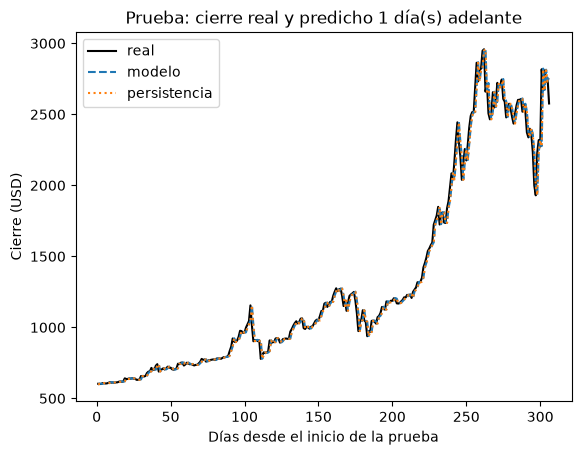

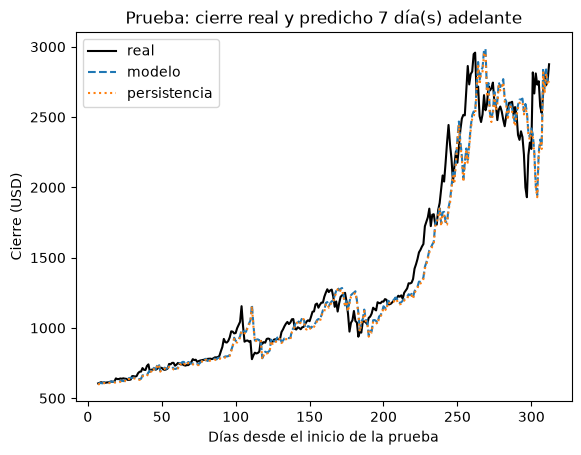

In [16]:
fechas = np.arange(len(origenes))
for h in (1, 7):
    plt.plot(fechas + h, real[:, h - 1], label="real", color="black")
    plt.plot(fechas + h, pred["modelo"][:, h - 1], label="modelo", linestyle="--")
    plt.plot(fechas + h, pred["persistencia"][:, h - 1], label="persistencia", linestyle=":")
    plt.xlabel("Días desde el inicio de la prueba")
    plt.ylabel("Cierre (USD)")
    plt.legend()
    plt.title("Prueba: cierre real y predicho %d día(s) adelante" % h)
    plt.show()

La predicción casi se superpone con la persistencia y llega con retraso a los cambios del precio real, que es lo esperable cuando predecir equivale a repetir el último valor.

### Modelo para servir y predicción

El modelo que se usa en la aplicación se reentrena con **todos** los días, para partir del último cierre real. Con todo el período, la deriva sube.

In [17]:
final = candidatos()[ganador].fit(X, y)
sigma_final = float(np.std(y - final.predict(X), ddof=1))
print("retorno medio diario con todos los días: %.5f" % final.named_steps["modelo"].intercept_)

ultimos = cierres[-VENTANA_MINIMA:]
estimacion = recursiva(final, [ultimos], 7)[0]
for dias in (1, 3, 7):
    amplitud = np.exp(1.96 * sigma_final * np.sqrt(dias))
    print("%d día(s) después del 31-jul-2017: %.2f USD (rango del 95 %%: %.0f a %.0f)" % (dias, estimacion[dias - 1], estimacion[dias - 1] / amplitud, estimacion[dias - 1] * amplitud))

retorno medio diario con todos los días: 0.00204
1 día(s) después del 31-jul-2017: 2881.62 USD (rango del 95 %: 2652 a 3131)
3 día(s) después del 31-jul-2017: 2893.64 USD (rango del 95 %: 2507 a 3340)
7 día(s) después del 31-jul-2017: 2917.90 USD (rango del 95 %: 2344 a 3633)


---
# Conclusiones
---

## Resultados

Para fines de predicción con su propio historial, el Bitcoin de 2013 a 2017 se comporta como un **paseo aleatorio con deriva**: ni los rezagos, ni las medias móviles, ni la volatilidad aportaron una ventaja medible sobre repetir el último precio, ni con el Ridge (coeficientes casi en 0) ni con los modelos de árboles. El modelo entregado reconoce eso: su pronóstico es "el último cierre más el crecimiento medio". Lo más útil que ofrece es el **rango del 95 %**, que crece con la raíz del horizonte y cubrió bien en la prueba.

Limitaciones: los datos terminan el 31 de julio de 2017 y el modelo no conoce el precio actual. La prueba es una sola ventana de un mercado alcista, así que la ventaja de dirección es engañosa y la deriva positiva se extrapola hacia adelante: en un mercado bajista el modelo seguiría prediciendo subidas. El intervalo supone volatilidad constante, aunque la serie muestra agrupamiento de volatilidad. Solo se usó el historial de cierres. **No es una recomendación de inversión.**

### Referencias

> Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *The Journal of Finance*, 25(2), 383-417.
> Künsch, H. R. (1989). The jackknife and the bootstrap for general stationary observations. *The Annals of Statistics*, 17(3), 1217-1241.
> Meese, R. A., & Rogoff, K. (1983). Empirical exchange rate models of the seventies: Do they fit out of sample? *Journal of International Economics*, 14(1-2), 3-24.
> Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3.ª ed.). OTexts.